# EE2213 Project: Multi-Class Classification

#### <span style="color:red">No additional library imports are permitted.</span>

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder

## PART 0: Data Loading and Preparation

In [48]:
def load_openml_dataset():

    dataset = fetch_openml(name='vehicle', version=1, as_frame=True, parser='auto')
    X = dataset.data.values
    
    target_values = dataset.target.values
    unique_targets = np.unique(target_values)
    
    # Create mapping from string labels to integers
    label_to_int = {label: i for i, label in enumerate(unique_targets)}
    y = np.array([label_to_int[label] for label in target_values])
    
    feature_names = dataset.feature_names
    
    return X, y, feature_names

X, y, feature_names = load_openml_dataset()
print(f"Feature shape: {X.shape}, target output shape:{y.shape}")
print(f"feature names: {feature_names}")


Feature shape: (846, 18), target output shape:(846,)
feature names: ['COMPACTNESS', 'CIRCULARITY', 'DISTANCE_CIRCULARITY', 'RADIUS_RATIO', 'PR.AXIS_ASPECT_RATIO', 'MAX.LENGTH_ASPECT_RATIO', 'SCATTER_RATIO', 'ELONGATEDNESS', 'PR.AXIS_RECTANGULARITY', 'MAX.LENGTH_RECTANGULARITY', 'SCALED_VARIANCE_MAJOR', 'SCALED_VARIANCE_MINOR', 'SCALED_RADIUS_OF_GYRATION', 'SKEWNESS_ABOUT_MAJOR', 'SKEWNESS_ABOUT_MINOR', 'KURTOSIS_ABOUT_MAJOR', 'KURTOSIS_ABOUT_MINOR', 'HOLLOWS_RATIO']


## PART 1: Dataset Partition and One-hot Encoding

In [49]:
def dataset_partition_encoding(X, y):
    """
    Input type
    :X type: numpy.ndarray of size (number_of_samples, number_of_features)
    :y type: numpy.ndarray of size (number_of_samples,)

    Return type
    :X_train type: numpy.ndarray of size (number_of_training_samples, number_of_features)
    :X_val type: numpy.ndarray of size (number_of_validation_samples, number_of_features)
    :X_test type: numpy.ndarray of size (number_of_test_samples, number_of_features)
    :Ytr_onehot type: numpy.ndarray of size (number_of_training_samples, num_classes)
    :Yval_onehot type: numpy.ndarray of size (number_of_validation_samples, num_classes)
    :Yts_onehot type: numpy.ndarray of size (number_of_test_samples, num_classes)

    """
    # your code goes here

    #First split into train and temp (val + test)
    X_train, X_test, Ytr, Ytest = train_test_split(X, y, random_state=812, train_size=0.6)
    #Then split temp into val and test
    X_val, X_test, Yval, Yts = train_test_split(X_test, Ytest, random_state=812, test_size=0.5)

    #Define one-hot encoder and use it, also reshape data into 2D matrix to encode
    onehot_encoder=OneHotEncoder(sparse_output=False)
    Ytr_onehot = onehot_encoder.fit_transform(Ytr.reshape(-1, 1))
    Yval_onehot = onehot_encoder.fit_transform(Yval.reshape(-1, 1))
    Yts_onehot = onehot_encoder.fit_transform(Yts.reshape(-1, 1))
    # return in this order
    return X_train, X_val, X_test, Ytr_onehot, Yval_onehot, Yts_onehot

X_train, X_val, X_test, Ytr_onehot, Yval_onehot, Yts_onehot = dataset_partition_encoding(X, y)
print(f"Training set shape: {X_train.shape}, {Ytr_onehot.shape}")
print(f"Validation set shape: {X_val.shape}, {Yval_onehot.shape}")
print(f"Test set shape: {X_test.shape}, {Yts_onehot.shape}")

Training set shape: (507, 18), (507, 4)
Validation set shape: (169, 18), (169, 4)
Test set shape: (170, 18), (170, 4)


## PART 2: Feature Selection using Pearson Correlation

In [50]:
def feature_selection(X_train, X_val, X_test, feature_names, threshold=0.8):
    """
    Input type
    :X_train type: numpy.ndarray of size (number_of_training_samples, number_of_features)
    :X_val type: numpy.ndarray of size (number_of_validation_samples, number_of_features)
    :X_test type: numpy.ndarray of size (number_of_test_samples, number_of_features)
    :feature_names type: list of str
    :threshold type: float

    Return type
    :selected_features type: list of str
    :FS_X_train type: numpy.ndarray of size (number_of_training_samples, number_of_selected_features)
    :FS_X_val type: numpy.ndarray of size (number_of_validation_samples, number_of_selected_features)
    :FS_X_test type: numpy.ndarray of size (number_of_test_samples, number_of_selected_features)

    """
    # your code goes here
    selected_features =[] # will store index and features
    for i, feature in enumerate(feature_names):
        # add default
        if len(selected_features) == 0: 
            selected_features.append([i,feature])
            continue

        added = 1
        for j, cur_feature in selected_features:
            if cur_feature == feature:
                continue
            first_col = X_train[:, i]
            second_col = X_train[:, j]

            #Calculate pearson coefficient, return matrix 2x2, take coefficient only
            pear_coefficient = np.corrcoef(first_col, second_col)[0, 1]

            if abs(pear_coefficient) >= threshold: # if too much correlation, don't add
                added = 0
                break
        if added : selected_features.append([i, feature])

    #Take index of the selected features
    index_features=[i for i, feature in selected_features if feature in feature_names]
    #Reshape selected_features from [x,2] back to [x,]. currently storing index and feature.
    #Aim : list contain feature only.
    selected_features = [cur[1] for cur in selected_features]

    #Reshape output, only take index of feature that we are selected
    FS_X_train = X_train[:, index_features]
    FS_X_val = X_val[:, index_features]
    FS_X_test = X_test[:, index_features]

    # return in this order
    return selected_features, np.array(FS_X_train), np.array(FS_X_val), np.array(FS_X_test)
selected_features, FS_X_train, FS_X_val, FS_X_test = feature_selection(X_train, X_val, X_test, feature_names)

print(f"{len(selected_features)} Selected Features: {selected_features}")
print(f"Training set shape after feature selection: {FS_X_train.shape}, {Ytr_onehot.shape}")
print(f"Validation set shape after feature selection: {FS_X_val.shape}, {Yval_onehot.shape}")
print(f"Test set shape after feature selection: {FS_X_test.shape}, {Yts_onehot.shape}")

10 Selected Features: ['COMPACTNESS', 'CIRCULARITY', 'DISTANCE_CIRCULARITY', 'RADIUS_RATIO', 'PR.AXIS_ASPECT_RATIO', 'MAX.LENGTH_ASPECT_RATIO', 'SKEWNESS_ABOUT_MAJOR', 'SKEWNESS_ABOUT_MINOR', 'KURTOSIS_ABOUT_MAJOR', 'KURTOSIS_ABOUT_MINOR']
Training set shape after feature selection: (507, 10), (507, 4)
Validation set shape after feature selection: (169, 10), (169, 4)
Test set shape after feature selection: (170, 10), (170, 4)


## PART 3: Polynomial Feature Transformation and Classification

In [51]:
def polynomial_for_classification(FS_X_train, FS_X_val, FS_X_test, Ytr_onehot, Yval_onehot, Yts_onehot, max_order=3, lamda=0.001):
    """
    Args:
        FS_X_train (np.ndarray): Feature matrix for training.
        FS_X_val (np.ndarray): Feature matrix for validation.
        FS_X_test (np.ndarray): Feature matrix for testing.
        Ytr_onehot (np.ndarray): One-hot encoded labels for training.
        Yval_onehot (np.ndarray): One-hot encoded labels for validation.
        Yts_onehot (np.ndarray): One-hot encoded labels for testing.
        max_order (int): Maximum polynomial order to consider.
        lamda (float): Regularization strength.

    Returns:
        acc_train_list (list): Training accuracies for each polynomial order.
        acc_val_list (list): Validation accuracies for each polynomial order.
        best_order (int): Best polynomial order based on validation accuracy.
        acc_test (float): Test accuracy for the best polynomial order.

    """

    # your code goes here
    acc_train_list = []
    acc_val_list = []
    acc_test_list = []

    for i in range(1, max_order+1,1):
        # Initialize poly function
        poly = PolynomialFeatures(i)
        P_X_train = poly.fit_transform(FS_X_train)
        P_X_val = poly.transform(FS_X_val)
        P_X_test = poly.transform(FS_X_test)

        P_sqr = P_X_train.T @ P_X_train
        rank = np.linalg.matrix_rank(P_sqr)
        if rank == P_sqr.shape[0]: # P_X_train.T @ P_X_train is invertible
            W = np.linalg.inv(P_sqr) @ P_X_train.T @ Ytr_onehot
        else: # doing L2 regularization with lamda factor = 0.001
            W = np.linalg.inv(P_sqr + 0.001 * np.eye(P_X_train.shape[1])) @ P_X_train.T @ Ytr_onehot
        
        # Predict with the weight
        Ytr_pred = P_X_train @ W 
        Yval_pred = P_X_val @ W 
        Ytest_pred = P_X_test @ W 

        # Calculate the accuracy, required only train and val accuracy, but we will need test accuracy so just compute
        acc_tr = accuracy_score(np.argmax(Ytr_pred, axis = 1), np.argmax(Ytr_onehot, axis = 1))
        acc_val = accuracy_score(np.argmax(Yval_pred, axis = 1), np.argmax(Yval_onehot, axis = 1))
        acc_test = accuracy_score(np.argmax(Ytest_pred, axis = 1), np.argmax(Yts_onehot, axis = 1))


        # add into list
        acc_train_list.append(acc_tr)
        acc_val_list.append(acc_val)
        acc_test_list.append(acc_test)

        
    best_order = np.argmax(acc_val_list) + 1 # best order in validation score
    acc_test = acc_test_list[best_order - 1] # Accuracy for best order test

    # return in this order              
    return acc_train_list, acc_val_list, best_order, acc_test

acc_train_list, acc_val_list, best_order, acc_test = polynomial_for_classification(FS_X_train, FS_X_val, FS_X_test, Ytr_onehot, Yval_onehot, Yts_onehot)

print(f"Training accuracies: {np.round(acc_train_list,2)}")
print(f"Validation accuracies: {np.round(acc_val_list,2)}")
print(f"Best polynomial order: {best_order}")
print(f"Test accuracy for best order {best_order}: {np.round(acc_test,2)}")


Training accuracies: [0.73 0.86 0.97]
Validation accuracies: [0.64 0.73 0.73]
Best polynomial order: 2
Test accuracy for best order 2: 0.76


## PART 4: Multinomial Logistic Regression

Without Normalization
Training accuracies for different learning rates: [0.64 0.45 0.44 0.49]
Validation accuracies for different learning rates: [0.59 0.45 0.44 0.47]
Best learning rate: 0.0001
Test accuracy for best learning rate 0.0001: 0.54
With Z-score Standardization
Training accuracies for different learning rates: [0.56 0.7  0.74 0.75]
Validation accuracies for different learning rates: [0.5  0.57 0.63 0.67]
Best learning rate: 0.1
Test accuracy for best learning rate 0.1: 0.73


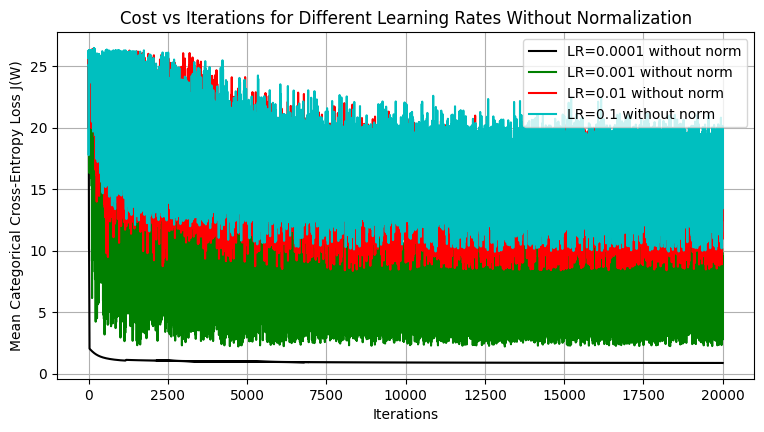

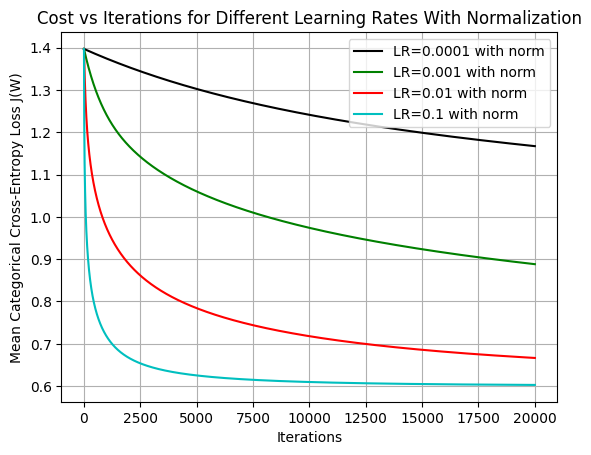

In [52]:
def MLR_select_lr(FS_X_train, FS_X_val, FS_X_test, Ytr_onehot, Yval_onehot, Yts_onehot, lr_list=[0.0001, 0.001, 0.01, 0.1], num_iters=20000):
    """
    Args:
        FS_X_train (np.ndarray): Feature matrix for training.
        FS_X_val (np.ndarray): Feature matrix for validation.
        FS_X_test (np.ndarray): Feature matrix for testing.
        Ytr_onehot (np.ndarray): One-hot encoded labels for training.
        Yval_onehot (np.ndarray): One-hot encoded labels for validation.
        Yts_onehot (np.ndarray): One-hot encoded labels for testing.
        lr_list (list): List of learning rates to test.
        num_iters (int): Number of iterations for training.

    Returns:
        cost_dict (dict): Dictionary of cost values for each learning rate without input normalization.
                          example: cost_dict = {0.0001: [0.1, 0.05, ...], 0.001: [0.09, 0.045, ...], ...}
        acc_train_list_Log (list): Training accuracies for each learning rate without input normalization.
        acc_val_list_Log (list): Validation accuracies for each learning rate without input normalization.
        best_lr (float): Best learning rate based on validation accuracy without input normalization.
        acc_test (float): Test accuracy for the best learning rate without input normalization.
        cost_dict_norm (dict): Dictionary of cost values for each learning rate with input normalization.
        acc_train_list_Log_norm (list): Training accuracies for each learning rate with input normalization.
        acc_val_list_Log_norm (list): Validation accuracies for each learning rate with input normalization.
        best_lr_norm (float): Best learning rate based on validation accuracy with input normalization.
        acc_test_norm (float): Test accuracy for the best learning rate with input normalization.

    """
    
    # your code goes here
    def pred_cost_gradient(X, W, Y, eps = 1e-15):
        # Reference L9 demo code

        # Result of X x W
        temp = X @ W
        temp_max = np.max(temp, axis = 1, keepdims=True) 
        
        # Softmax of X x W = F_W(X)
        esp_temp = np.exp(temp - temp_max) # prevent overflow for power of e
        pred_Y = esp_temp/np.sum(esp_temp, axis = 1, keepdims=True) # Still have dimension of (n samples, k classes)
        pred_Y = np.clip(pred_Y, eps, 1 - eps) # Ensure enough resolution

        # calculate gradient = 1/N x X.Tx(F_W(X) - Y) and cost 
        gradient = X.T @ (pred_Y - Y)/X.shape[0]
        cost = np.sum(-(Y * np.log(pred_Y)))/X.shape[0]

        return pred_Y, cost, gradient
    
    # Split into two case, both with same input as parent function, just with activation for standard scaler or not
    def calculate_half (FS_X_train, FS_X_val, FS_X_test, Ytr_onehot, Yval_onehot, Yts_onehot, lr_list, num_iters, activation):
        # Variable declare
        cost_dict = {}
        acc_train_list_Log = []
        acc_val_list_Log = []


        # No input normalization
        # Create random seed for reproducibility
        np.random.seed(812) 
        # Create input with bias 
        if not activation :
            ones = np.ones((FS_X_train.shape[0], 1))
            P_X_train = np.hstack((ones, FS_X_train))
            ones = np.ones((FS_X_val.shape[0], 1))
            P_X_val = np.hstack((ones, FS_X_val))
            ones = np.ones((FS_X_test.shape[0], 1))
            P_X_ts = np.hstack((ones, FS_X_test))
        else:
            scaler = StandardScaler()
            Pre_X_train = scaler.fit_transform(FS_X_train)
            Pre_X_val = scaler.transform(FS_X_val)
            Pre_X_ts = scaler.transform(FS_X_test)

            ones = np.ones((Pre_X_train.shape[0], 1))
            P_X_train = np.hstack((ones, Pre_X_train))
            ones = np.ones((Pre_X_val.shape[0], 1))
            P_X_val = np.hstack((ones, Pre_X_val))
            ones = np.ones((Pre_X_ts.shape[0], 1))
            P_X_ts = np.hstack((ones, Pre_X_ts))

        # Random weight, Shape = (n_features + 1 bias, num_classes), 
        W_init = np.random.normal(0, 0.1, (P_X_train.shape[1], Ytr_onehot.shape[1]))  
        W_list = [] # to store weight to compare later

        for learning_rate in lr_list: # For each learning rate
            cost_list = []
            W = W_init.copy() # keep the new initial weight for every learning rate
            _,cost,_ = pred_cost_gradient(P_X_train, W, Ytr_onehot, eps = 1e-15)
            cost_list.append(cost)
            for i in range(1, num_iters+1):  # number of iterations with respective learning rate
                ## Calculate gradient and cost
                pred_Y, cost, gradient = pred_cost_gradient(P_X_train, W, Ytr_onehot, eps = 1e-15)

                ## Apply gradient
                W = W - learning_rate * gradient
                
                ## Attach cost
                cost_list.append(cost)
            
            # Update cost_dict, accuracy for each learning rate.
            cost_dict[learning_rate] = cost_list
            
            # Accuracy calculation for training
            pred_Y, cost, gradient = pred_cost_gradient(P_X_train, W, Ytr_onehot, eps = 1e-15)
            acc_tr = accuracy_score(np.argmax(pred_Y, axis = 1), np.argmax(Ytr_onehot, axis = 1))
            acc_train_list_Log.append(acc_tr)

            # Accuracy calculation for validation
            pred_Y, cost, gradient = pred_cost_gradient(P_X_val, W, Yval_onehot, eps = 1e-15)
            acc_val = accuracy_score(np.argmax(pred_Y, axis = 1), np.argmax(Yval_onehot, axis = 1))
            acc_val_list_Log.append(acc_val)
            W_list.append(W)

        # Best learning rate and accuracy for test
        best_idx = np.argmax(acc_val_list_Log) # index for best val accuracy
        best_lr = lr_list[best_idx] # Best learning rate for val accuracy

        pred_Y, cost, gradient = pred_cost_gradient(P_X_ts, W_list[best_idx], Yts_onehot, eps = 1e-15)
        test_acc_Log = accuracy_score(np.argmax(pred_Y, axis = 1), np.argmax(Yts_onehot, axis = 1))
        return cost_dict,acc_train_list_Log, acc_val_list_Log, best_lr,test_acc_Log

    # Calling the function with same argument just different with the last to be activated!
    cost_dict,acc_train_list_Log, acc_val_list_Log, best_lr, test_acc_Log = calculate_half (FS_X_train, FS_X_val, FS_X_test, Ytr_onehot, Yval_onehot, Yts_onehot, lr_list, num_iters, False)
    cost_dict_norm, acc_train_list_Log_norm, acc_val_list_Log_norm, best_lr_norm, test_acc_Log_norm = calculate_half (FS_X_train, FS_X_val, FS_X_test, Ytr_onehot, Yval_onehot, Yts_onehot, lr_list, num_iters, True)
    
    # return in this order   
    return cost_dict,acc_train_list_Log, acc_val_list_Log, best_lr, test_acc_Log, cost_dict_norm, acc_train_list_Log_norm, acc_val_list_Log_norm, best_lr_norm, test_acc_Log_norm




def cost_vs_iter_curve (cost_dict, cost_dict_norm):
    """
    Args:
        cost_dict (dict): Dictionary of cost values for each learning rate without input normalization.
        cost_dict_norm (dict): Dictionary of cost values for each learning rate with input normalization.

    """
    color_list = ["k", "g", "r", "c"]
    lr_list = [0.0001, 0.001, 0.01, 0.1]
    plt.figure(figsize=[9,4.5])
    

    for color, lr in zip(color_list, lr_list):
        cost_list = cost_dict[lr]           # without normalization
        
        plt.plot(cost_list, color=color, linestyle='-', label=f'LR={lr} without norm')
        # plt.plot(cost_list_norm, color=color, linestyle='--', label=f'LR={lr} with norm')
    
    plt.xlabel('Iterations')
    plt.ylabel('Mean Categorical Cross-Entropy Loss J(W)')
    plt.title('Cost vs Iterations for Different Learning Rates Without Normalization')
    plt.legend()
    plt.grid(True)
    plt.show()

    for color, lr in zip(color_list, lr_list):
        cost_list = cost_dict_norm[lr]           # wit normalization
        
        plt.plot(cost_list, color=color, linestyle='-', label=f'LR={lr} with norm')
    
    plt.xlabel('Iterations')
    plt.ylabel('Mean Categorical Cross-Entropy Loss J(W)')
    plt.title('Cost vs Iterations for Different Learning Rates With Normalization')
    plt.legend()
    plt.grid(True)
    plt.show()



cost_dict,acc_train_list_Log, acc_val_list_Log, best_lr,test_acc_Log, cost_dict_norm, acc_train_list_Log_norm, acc_val_list_Log_norm, best_lr_norm, test_acc_Log_norm = MLR_select_lr(FS_X_train, FS_X_val, FS_X_test, Ytr_onehot, Yval_onehot, Yts_onehot)

print(f"Without Normalization")
print(f"Training accuracies for different learning rates: {np.round(acc_train_list_Log,2)}")
print(f"Validation accuracies for different learning rates: {np.round(acc_val_list_Log,2)}")
print(f"Best learning rate: {best_lr}")
print(f"Test accuracy for best learning rate {best_lr}: {np.round(test_acc_Log,2)}")


print(f"With Z-score Standardization")
print(f"Training accuracies for different learning rates: {np.round(acc_train_list_Log_norm,2)}")
print(f"Validation accuracies for different learning rates: {np.round(acc_val_list_Log_norm,2)}")
print(f"Best learning rate: {best_lr_norm}")
print(f"Test accuracy for best learning rate {best_lr_norm}: {np.round(test_acc_Log_norm,2)}")

cost_vs_iter_curve (cost_dict, cost_dict_norm)

### Analysis of Effect of Normalization Based on Your Results

##### It is clear that for the learning without normalization, the loss function ossiclates very fast with slightly larger learning rate (larger than 0.0001) and only 0.0001 learning rate will eventually converge in this scenario.
##### However, for normalization for multinomial logistic regression, the loss function will eventually converge regardless of the learning rate. Also, larger learning rate tends to converge quicklier compared to lower one. This indicates that the effect of normalization has smoothened the learning of the model.
##### This could be because of imbalanced magnitude of data from the beginning, in which some may be dominant over tiny others. So even small gradient could dramatically change the loss function of the training. But when we do z-score standardization, it makes every feature has the same impact on the gradient, thus making the gradient descent always stable to the local minimum.